# 第 6 讲：IMU 安装误差——坐标标定与控制状态构造

我们的 IMU 已经能够输出姿态和角速度，因此没有必要为了获得 $\dot\phi$ 而先引入状态观测器。真正容易被忽略的问题是：**IMU 的三个轴通常不会与自行车车体轴完全重合**。

如果直接把 IMU 的 x 轴角速度当成滚转角速度，一个只有几度的安装偏差也会把俯仰和偏航角速度混入平衡反馈。由于控制器会快速放大状态误差，这种坐标错误可能比普通白噪声更危险。

本讲目标：

1. 区分世界坐标系、自行车坐标系和 IMU 坐标系；
2. 用固定旋转 $R_{BS}$ 修正安装误差；
3. 正确变换角速度和姿态，避免直接减欧拉角；
4. 用静止数据估计陀螺零偏，用多轴运动估计安装旋转；
5. 构造控制器需要的 $x=[\delta,\phi,\dot\phi]^T$。

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
from scipy.spatial.transform import Rotation

project_root = Path.cwd()
if not (project_root / "nominal_bike_control").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from nominal_bike_control import NominalBikeController, ScaleBikeModel

np.set_printoptions(precision=5, suppress=True)
plt.style.use("seaborn-v0_8-bright")
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
chinese_font = next((name for name in ["Arial Unicode MS", "PingFang HK", "Noto Sans CJK SC", "SimHei"] if name in available_fonts), "DejaVu Sans")
plt.rcParams.update({"font.sans-serif": [chinese_font], "axes.unicode_minus": False})


## 1. 三个坐标系与统一记号

本讲采用右手坐标系：

- 世界坐标系 $W$：固定在地面；
- 自行车坐标系 $B$：x 向前、y 向左、z 向上；
- IMU 坐标系 $S$：由传感器外壳和安装方向决定。

定义 $R_{AB}$ 为“把 B 系坐标变换成 A 系坐标”的旋转：

$$v_A=R_{AB}v_B$$

固定安装误差用 $R_{BS}$ 表示，所以 IMU 测到的角速度应转换为

$$\omega_B=R_{BS}(\omega_S-b_S)$$

其中 $b_S$ 是在 IMU 坐标系中表示的陀螺零偏。零偏必须先在 S 系中减掉，再进行坐标旋转。

In [2]:
def rotation_from_rpy_deg(roll_pitch_yaw_deg):
    """由 roll/pitch/yaw 角构造旋转；内部使用标准 Z-Y-X 组合。"""
    roll, pitch, yaw = np.deg2rad(roll_pitch_yaw_deg)
    return Rotation.from_euler("ZYX", [yaw, pitch, roll])


def rpy_deg_from_rotation(rotation):
    yaw, pitch, roll = rotation.as_euler("ZYX")
    return np.rad2deg([roll, pitch, yaw])


# 示例：R_BS 把 IMU 坐标中的向量转换到自行车坐标。
sensor_to_bike = rotation_from_rpy_deg([4.0, -3.0, 7.0])
print("假设的安装误差 [roll, pitch, yaw] (deg) =", rpy_deg_from_rotation(sensor_to_bike))
print("R_BS =\n", sensor_to_bike.as_matrix())
print("正交检查 R.T @ R =\n", sensor_to_bike.as_matrix().T @ sensor_to_bike.as_matrix())


假设的安装误差 [roll, pitch, yaw] (deg) = [ 4. -3.  7.]
R_BS =
 [[ 0.99119 -0.1252  -0.04332]
 [ 0.1217   0.98968 -0.0756 ]
 [ 0.05234  0.06966  0.9962 ]]
正交检查 R.T @ R =
 [[ 1.  0. -0.]
 [ 0.  1.  0.]
 [-0.  0.  1.]]


安装误差不是三个传感器通道分别加一个常数。例如，自行车只绕 B 系 x 轴滚转时，IMU 的 x、y、z 三个陀螺通道通常都会有输出。正确做法是对三维向量乘旋转矩阵，而不是只修正 `gyro_x`。

## 2. 安装误差如何污染滚转角速度

下面构造一段包含滚转、俯仰和偏航运动的角速度。先把真实自行车角速度变换到 IMU 坐标系，再加入固定零偏和噪声。比较三种结果：

1. 直接使用 IMU x 通道；
2. 只减零偏但不修正安装角；
3. 减零偏并用 $R_{BS}$ 转回自行车坐标系。

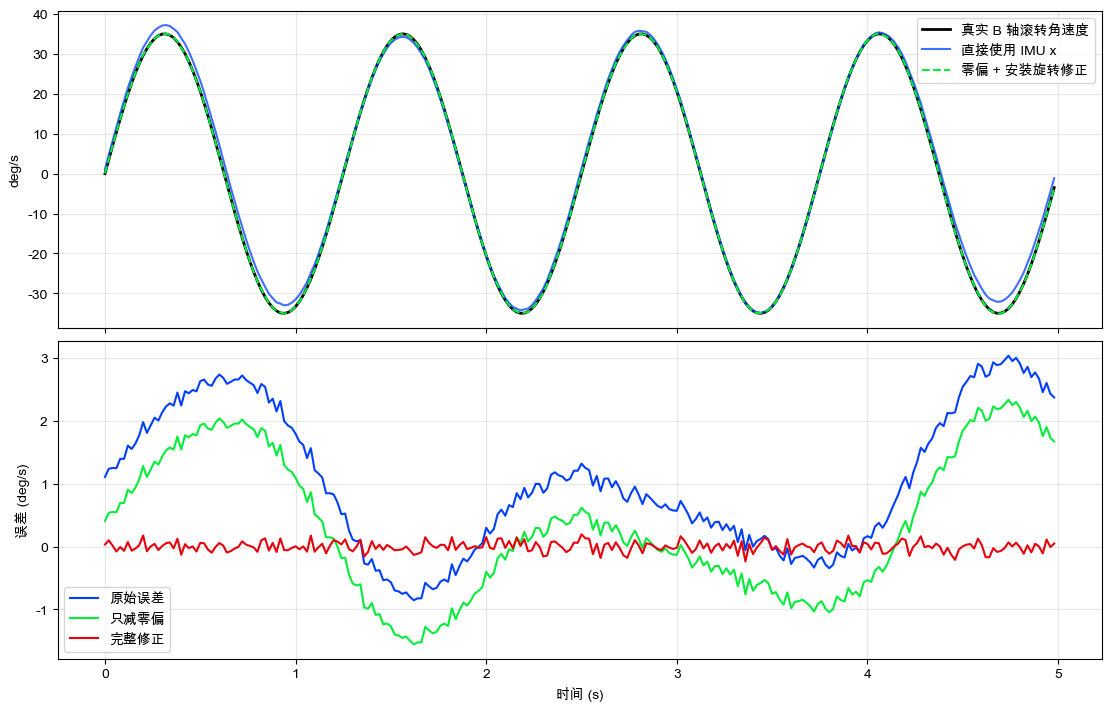

直接使用 IMU x       RMS 误差 = 1.5005 deg/s
只减零偏             RMS 误差 = 1.1426 deg/s
完整修正             RMS 误差 = 0.0811 deg/s


In [3]:
rng = np.random.default_rng(42)
sample_time = 0.02
time = np.arange(0.0, 5.0, sample_time)

omega_b_true = np.column_stack([
    np.deg2rad(35.0) * np.sin(2.0 * np.pi * 0.8 * time),
    np.deg2rad(12.0) * np.sin(2.0 * np.pi * 0.45 * time + 0.4),
    np.deg2rad(18.0) * np.sin(2.0 * np.pi * 0.30 * time - 0.2),
])

gyro_bias_s = np.deg2rad([0.7, -0.4, 0.25])
gyro_noise_std = np.deg2rad(0.08)
omega_s_measured = (
    sensor_to_bike.inv().apply(omega_b_true)
    + gyro_bias_s
    + rng.normal(0.0, gyro_noise_std, omega_b_true.shape)
)

raw_roll_rate = omega_s_measured[:, 0]
bias_only_roll_rate = (omega_s_measured - gyro_bias_s)[:, 0]
omega_b_corrected = sensor_to_bike.apply(omega_s_measured - gyro_bias_s)
corrected_roll_rate = omega_b_corrected[:, 0]

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, constrained_layout=True)
axes[0].plot(time, np.rad2deg(omega_b_true[:, 0]), color="black", linewidth=2, label="真实 B 轴滚转角速度")
axes[0].plot(time, np.rad2deg(raw_roll_rate), alpha=0.75, label="直接使用 IMU x")
axes[0].plot(time, np.rad2deg(corrected_roll_rate), linestyle="--", label="零偏 + 安装旋转修正")
axes[0].set_ylabel("deg/s")
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[1].plot(time, np.rad2deg(raw_roll_rate - omega_b_true[:, 0]), label="原始误差")
axes[1].plot(time, np.rad2deg(bias_only_roll_rate - omega_b_true[:, 0]), label="只减零偏")
axes[1].plot(time, np.rad2deg(corrected_roll_rate - omega_b_true[:, 0]), label="完整修正")
axes[1].set_xlabel("时间 (s)")
axes[1].set_ylabel("误差 (deg/s)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.show()

for name, estimate in [("直接使用 IMU x", raw_roll_rate), ("只减零偏", bias_only_roll_rate), ("完整修正", corrected_roll_rate)]:
    rms = np.rad2deg(np.sqrt(np.mean((estimate - omega_b_true[:, 0]) ** 2)))
    print(f"{name:16s} RMS 误差 = {rms:.4f} deg/s")


## 3. 姿态不能直接减安装欧拉角

假设 IMU 姿态解算输出 $R_{WS}$，表示传感器相对世界的姿态。因为安装关系固定，满足

$$R_{WS}=R_{WB}R_{BS}$$

所以自行车姿态为

$$R_{WB}=R_{WS}R_{SB}=R_{WS}R_{BS}^{T}$$

旋转的乘法通常不可交换。除极小角度外，`IMU 欧拉角 - 安装欧拉角` 不等于正确姿态。应先组合旋转矩阵或四元数，最后才转换成滚转角。

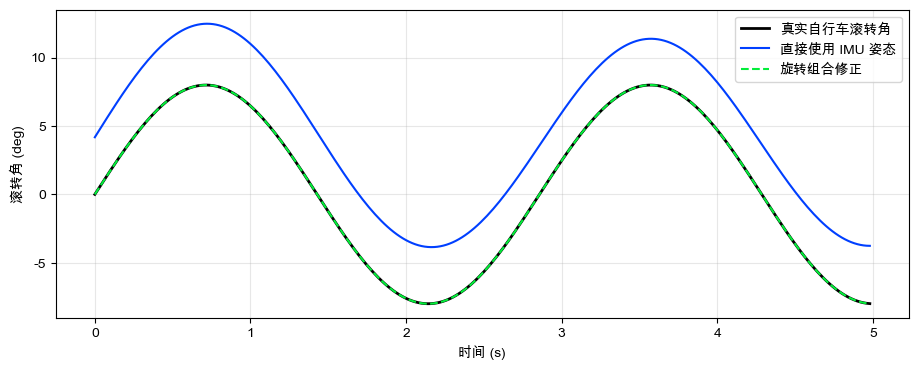

修正后最大滚转角误差 (deg) = 4.770832022195275e-15


In [4]:
roll_true = np.deg2rad(8.0) * np.sin(2.0 * np.pi * 0.35 * time)
pitch_true = np.deg2rad(5.0) * np.sin(2.0 * np.pi * 0.20 * time + 0.3)
yaw_true = np.deg2rad(20.0) * np.sin(2.0 * np.pi * 0.10 * time)

world_from_bike = Rotation.from_euler("ZYX", np.column_stack([yaw_true, pitch_true, roll_true]))
world_from_sensor = world_from_bike * sensor_to_bike

# 错误做法：把传感器姿态直接当成自行车姿态。
raw_yaw_pitch_roll = world_from_sensor.as_euler("ZYX")
raw_roll = raw_yaw_pitch_roll[:, 2]

# 正确做法：先消除固定安装旋转，再提取欧拉角。
world_from_bike_est = world_from_sensor * sensor_to_bike.inv()
corrected_yaw_pitch_roll = world_from_bike_est.as_euler("ZYX")
corrected_roll = corrected_yaw_pitch_roll[:, 2]

plt.figure(figsize=(11, 4))
plt.plot(time, np.rad2deg(roll_true), color="black", linewidth=2, label="真实自行车滚转角")
plt.plot(time, np.rad2deg(raw_roll), label="直接使用 IMU 姿态")
plt.plot(time, np.rad2deg(corrected_roll), linestyle="--", label="旋转组合修正")
plt.xlabel("时间 (s)")
plt.ylabel("滚转角 (deg)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
print("修正后最大滚转角误差 (deg) =", np.rad2deg(np.max(np.abs(corrected_roll - roll_true))))


## 4. 怎样标定 $R_{BS}$ 和陀螺零偏

推荐分两步标定：

### 第一步：静止零偏

固定自行车并保持静止数秒，在 IMU 原始坐标系中计算三轴陀螺均值：

$$\hat b_S=\frac{1}{N}\sum_{k=1}^{N}\omega_S[k]$$

不要用正在运动的数据估计零偏。温度变化明显时，应记录温度并重新标定。

### 第二步：多轴安装旋转

采集若干组已知自行车角速度 $\omega_B^{(i)}$ 和去偏后的 IMU 角速度 $\omega_S^{(i)}$，求解 Wahba 问题：

$$\min_{R_{BS}\in SO(3)}\sum_i\|\omega_B^{(i)}-R_{BS}\omega_S^{(i)}\|^2$$

只绕一个轴晃动车体不足以确定完整三维旋转；需要至少两个不共线方向，最好让三个轴都有充分激励。静止重力可以帮助确定倾斜，但不能单独确定绕重力方向的安装偏航角。

In [5]:
rng = np.random.default_rng(7)
stationary_samples = gyro_bias_s + rng.normal(0.0, np.deg2rad(0.05), (1000, 3))
gyro_bias_est = stationary_samples.mean(axis=0)

# 教学示例中的 omega_b_cal 由外部参考得到；实车可使用高精度夹具、
# 已知转轴动作或独立运动捕捉系统提供参考。
omega_b_cal = rng.normal(0.0, np.deg2rad(25.0), (800, 3))
omega_s_cal = (
    sensor_to_bike.inv().apply(omega_b_cal)
    + gyro_bias_s
    + rng.normal(0.0, np.deg2rad(0.10), omega_b_cal.shape)
)

sensor_to_bike_est, rssd = Rotation.align_vectors(
    omega_b_cal, omega_s_cal - gyro_bias_est
)
rotation_error = sensor_to_bike_est * sensor_to_bike.inv()

print("真实安装角 [roll, pitch, yaw] (deg) =", rpy_deg_from_rotation(sensor_to_bike))
print("估计安装角 [roll, pitch, yaw] (deg) =", rpy_deg_from_rotation(sensor_to_bike_est))
print("零偏真实值 (deg/s) =", np.rad2deg(gyro_bias_s))
print("零偏估计值 (deg/s) =", np.rad2deg(gyro_bias_est))
print("安装旋转角误差 (deg) =", np.rad2deg(rotation_error.magnitude()))
print("align_vectors rssd =", rssd)


真实安装角 [roll, pitch, yaw] (deg) = [ 4. -3.  7.]
估计安装角 [roll, pitch, yaw] (deg) = [ 4.00177 -2.99621  7.00364]
零偏真实值 (deg/s) = [ 0.7  -0.4   0.25]
零偏估计值 (deg/s) = [ 0.69759 -0.40232  0.25004]
安装旋转角误差 (deg) = 0.005606396333378241
align_vectors rssd = 0.08292838199971587


## 5. 从真实 IMU 数据构造控制状态

下面给出一个可移植到实车接口的函数。约定 IMU 姿态四元数使用 SciPy 的 `xyzw` 顺序，并表示 $R_{WS}$。如果你的 SDK 输出 `wxyz`、输出的是 $R_{SW}$，或者使用 NED 坐标系，必须先按厂家文档转换。

陀螺仪给出的是车体角速度分量 $[p,q,r]$。一般情况下 $p$ 不严格等于欧拉滚转角导数：

$$\dot\phi=p+\sin\phi\tan\theta\,q+\cos\phi\tan\theta\,r$$

自行车接近直立且俯仰角很小时可用 $\dot\phi\approx p$；下面函数保留了完整换算。

In [6]:
def build_bicycle_state(steering_angle, imu_quaternion_xyzw, gyro_s,
                         sensor_to_bike_rotation, gyro_bias_sensor):
    world_from_sensor = Rotation.from_quat(np.asarray(imu_quaternion_xyzw, dtype=float))
    world_from_bike = world_from_sensor * sensor_to_bike_rotation.inv()
    yaw, pitch, roll = world_from_bike.as_euler("ZYX")

    p, q, r = sensor_to_bike_rotation.apply(
        np.asarray(gyro_s, dtype=float) - np.asarray(gyro_bias_sensor, dtype=float)
    )
    cos_pitch = np.cos(pitch)
    if abs(cos_pitch) < 1e-3:
        raise ValueError("Pitch is too close to the Euler-angle singularity.")
    roll_rate = p + np.sin(roll) * np.tan(pitch) * q + np.cos(roll) * np.tan(pitch) * r

    state = np.array([[steering_angle], [roll], [roll_rate]])
    return state, {"roll": roll, "pitch": pitch, "yaw": yaw,
                   "body_rates": np.array([p, q, r])}


sample_index = 80
state, diagnostics = build_bicycle_state(
    steering_angle=np.deg2rad(1.0),
    imu_quaternion_xyzw=world_from_sensor[sample_index].as_quat(),
    gyro_s=omega_s_measured[sample_index],
    sensor_to_bike_rotation=sensor_to_bike,
    gyro_bias_sensor=gyro_bias_s,
)
print("控制状态 [delta, phi, phi_dot] =\n", state)
print("诊断量 =", diagnostics)


控制状态 [delta, phi, phi_dot] =
 [[ 0.01745]
 [-0.0514 ]
 [ 0.60595]]
诊断量 = {'roll': -0.05139988401423169, 'pitch': 0.06445395469003845, 'yaw': 0.2947260453308712, 'body_rates': array([ 0.59895, -0.20487,  0.09799])}


## 6. 接入当前名义控制器

安装旋转、零偏和单位转换都应在进入控制器前完成。控制器只接收已经统一到自行车坐标系、单位为弧度和弧度每秒的状态。

In [7]:
bike = ScaleBikeModel(dt=0.02, track_roll=False, forward_speed=2.0)
controller = NominalBikeController(
    bike.sys, method="place_multiple_poles", wc=-5.0,
    u_min=-10.0, u_max=10.0,
)
steering_velocity_command = controller.step([[0.0]], state)[0, 0]
print("期望转向角速度 =", steering_velocity_command, "rad/s")


期望转向角速度 = -0.893561600665073 rad/s


## 7. 实车实施顺序与验收

建议按以下顺序进行，不要一上来就闭合平衡环：

1. **确认协议**：四元数顺序、世界坐标约定、旋转方向、角速度单位和时间戳；
2. **确认轴方向**：手动向左滚转、抬车头、向左偏航，检查三个车体轴的符号；
3. **静止标定**：采集 5–20 秒陀螺数据，估计 $b_S$ 和噪声标准差；
4. **安装标定**：使用多轴动作估计 $R_{BS}$，并把标定结果持久化；
5. **离线回放**：比较修正前后滚转角、滚转角速度和交叉轴耦合；
6. **低增益上车**：先架空或使用安全支撑，检查控制方向，再逐步提高增益；
7. **记录诊断量**：保存原始 IMU、修正后状态、控制指令、饱和标志和时间戳。

滤波只能减小随机噪声，不能修复坐标系错误。应先完成单位、零偏和安装旋转修正，再根据频谱选择低通滤波截止频率。过强滤波会增加相位延迟，可能降低平衡裕度。

## 8. 状态观测器现在放在哪里？

在 IMU 姿态和角速度都可靠时，主控制链直接使用测量状态，不需要 Luenberger 观测器。状态观测器仍可作为选修内容，用于传感器丢包、角速度不可用、融合多种传感器或进行故障检测，但它不能替代安装标定：如果测量轴本身定义错了，观测器也会把错误坐标的数据当成真实测量。

## 练习

1. 把安装误差从 `[4,-3,7]` 攁成 `[10,5,-15]`，比较修正前后的滚转角速度 RMS 误差。
2. 只使用绕自行车 x 轴的标定动作，再调用 `align_vectors`，观察为什么某些安装方向难以确定。
3. 故意把 `R_BS` 写成它的转置，检查控制状态的符号和交叉轴误差。
4. 将俯仰角增大到 $25^\circ$，比较车体角速度 $p$ 与欧拉滚转角速度 $\dot\phi$。
5. 模拟温度变化导致陀螺零偏缓慢漂移，比较固定零偏和分温区标定。
6. 根据你们真实 IMU 的通信协议，改写 `build_bicycle_state` 的四元数顺序和世界坐标转换，并用手工动作完成符号验收。